In [ ]:
import numpy
import pandas as pd
from pathlib import Path 
import torch

import matplotlib.pyplot as plt

In [ ]:
parent_dir = Path("anphy_sleep_data") 
parent_dir = parent_dir.joinpath("patient_records")
raw_dir = parent_dir.joinpath("raw")
clean_dir = parent_dir.joinpath("clean")

In [ ]:
data = torch.load(clean_dir / f"EPCTL01_dataset.pt",  weights_only=False)
X = data["X"]
y = data["y"]

In [ ]:
df = pd.DataFrame(X[0, :, :].T)
df

In [ ]:
df.corr()

In [ ]:
y

# Channel Descriptions

## EEG – Brain Electrical Activity
These electrodes measure voltage fluctuations from neuronal firing in the cortex. In sleep research they are used to identify sleep stages, detect sleep spindles, K-complexes, slow waves, and general brain rhythms.

### Prefrontal Cortex
**Fp1, Fp2**  
Measure activity from the left and right frontopolar regions. These channels are useful for detecting slow waves and frontal sleep dynamics.

### Frontal Cortex
**F3, F4**  
Measure left and right frontal brain activity. Frontal regions are important for slow wave sleep and sleep spindle propagation.

### Lateral Frontal Cortex
**F7, F8**  
Record activity from the lateral frontal lobes and can help observe hemispheric asymmetries or localized cortical activity.

### Additional Frontal Electrodes
**F1, F2, F5, F6, F9, F10, F11, F12**  
Provide denser spatial coverage of the frontal cortex to capture more detailed frontal brain activity patterns.

### Midline Frontal
**FZ**  
Measures activity along the centerline of the frontal cortex.

---

### Central Cortex
**C3, C4**  
Located over the sensorimotor cortex. These are commonly used primary EEG channels in sleep scoring.

### Additional Central Electrodes
**C1, C2, C5, C6**  
Provide finer sampling of neural activity over the central brain region.

### Midline Central
**CZ**  
Measures activity from the center of the sensorimotor cortex.

---

### Parietal Cortex
**P3, P4**  
Capture activity from the parietal lobes and are useful for observing sleep spindles and cortical rhythms.

### Additional Parietal Electrodes
**P1, P2, P5, P6, P9, P10, P11, P12**  
Provide higher-resolution coverage of parietal brain activity.

### Midline Parietal
**PZ**  
Measures activity from the center of the parietal cortex.

---

### Occipital Cortex
**O1, O2**  
Record activity from visual cortex regions. Alpha rhythms are commonly detected here.

### Midline Occipital
**OZ**  
Measures visual cortex activity along the midline.

---

### Parieto-Occipital Region
**PO3, PO4, PO7, PO8, POZ**  
Measure activity between the parietal and occipital lobes.

---

### Anterior Frontal Region
**AF3, AF4, AF7, AF8, AFZ**  
Measure activity between frontal and prefrontal regions and capture frontal network activity.

### Frontopolar Midline
**FPZ**  
Measures activity from the very front midline of the brain.

---

### Fronto-Central Region
**FC1, FC2, FC3, FC4, FC5, FC6, FCZ**  
Capture activity between frontal and central cortical regions.

---

### Fronto-Temporal Region
**FT7, FT8, FT9, FT10, FT11, FT12**  
Measure activity between frontal and temporal brain regions.

---

### Temporal Cortex
**T3, T4**  
Record activity from the temporal lobes and are commonly used in EEG analysis for temporal rhythms.

### Posterior Temporal
**T5, T6**  
Measure activity near the back of the temporal lobes.

### Inferior Temporal
**T9, T10**  
Additional temporal electrodes capturing lower temporal activity.

---

### Temporo-Parietal Region
**TP7, TP8, TP9, TP10, TP11, TP12**  
Record signals from the region between the temporal and parietal lobes.

---

### Centro-Parietal Region
**CP1, CP2, CP3, CP4, CP5, CP6, CPZ**  
Measure activity between central and parietal brain areas.

---

## Orbital / Facial Electrodes

### Supraorbital Electrodes
**SO1, SO2**  
Placed above the eye sockets. Often used for detecting eye movements or frontal activity related to REM sleep.

### Zygomatic Electrodes
**ZY1, ZY2**  
Placed near the cheekbones and often used to capture facial muscle activity or assist with artifact detection.

---

# Physiological Channels

## EOG – Eye Movement Signals
Used to detect rapid eye movements, which are essential for identifying REM sleep.

**EOG1, EOG2**  
Measure electrical potentials generated by eye movement.

---

## EMG – Muscle Activity
Used to detect muscle tone changes. Muscle tone decreases significantly during REM sleep.

**ChEMG1, ChEMG2**  
Chin electromyography channels that measure muscle activity under the chin to track muscle tone and detect REM atonia.

---

## ECG – Heart Activity
Measures electrical activity of the heart.

**ECG1, ECG2**  
Electrocardiogram channels that capture cardiac rhythms and heart rate variability.

---

# Limb Movement Sensors

**RLEG-, RLEG+**  
Right leg EMG electrodes used to measure muscle activity in the right leg and detect periodic limb movements during sleep.

**LLEG-, LLEG+**  
Left leg EMG electrodes used to measure muscle activity in the left leg.

These electrodes may also function as differential reference pairs depending on the recording configuration.

In [ ]:
CHANNEL_IND_X_MAP = {

    # Frontal / Prefrontal
    "Fp1": 0,  "Fp2": 1,
    "F3": 2,   "F4": 3,
    "F7": 10,  "F8": 11,
    "F9": 21,  "F10": 22,
    "F11": 31, "F5": 32, "F1": 33,
    "F2": 59,  "F6": 60, "F12": 61,
    "FZ": 16,

    # Central
    "C3": 4,   "C4": 5,
    "C5": 41,  "C1": 42,
    "C6": 68,  "C2": 69,
    "CZ": 17,

    # Parietal
    "P3": 6,   "P4": 7,
    "P9": 27,  "P10": 28,
    "P11": 48, "P5": 49, "P1": 50,
    "P2": 77,  "P6": 78, "P12": 79,
    "PZ": 18,

    # Occipital
    "O1": 8, "O2": 9,
    "OZ": 54,

    # Temporal
    "T3": 12, "T4": 13,
    "T5": 14, "T6": 15,
    "T9": 25, "T10": 26,

    # Anterior Frontal (AF)
    "AF7": 29, "AF3": 30,
    "AFZ": 56,
    "AF4": 57, "AF8": 58,

    # Fronto-Central (FC)
    "FC5": 37, "FC3": 38, "FC1": 39,
    "FCZ": 40,
    "FC2": 62, "FC4": 63, "FC6": 64,

    # Fronto-Temporal (FT)
    "FT11": 34, "FT9": 35, "FT7": 36,
    "FT8": 65,  "FT10": 66, "FT12": 67,

    # Temporo-Parietal (TP)
    "TP11": 43, "TP9": 44, "TP7": 45,
    "TP8": 74,  "TP10": 75, "TP12": 76,

    # Centro-Parietal (CP)
    "CP3": 46, "CP1": 47,
    "CPZ": 70,
    "CP2": 71, "CP4": 72, "CP6": 73,
    "CP5": 92,  # likely should be 92

    # Parieto-Occipital (PO)
    "PO7": 51, "PO3": 52, "POZ": 53,
    "PO4": 80, "PO8": 81,

    # Midline Front
    "FPZ": 55,

    # Orbital / Face
    "SO1": 19, "SO2": 20,
    "ZY1": 23, "ZY2": 24,

    # Physiological Sensors
    "ChEMG1": 82,
    "ChEMG2": 83,

    # Limb EMG
    "RLEG-": 84, "RLEG+": 85,
    "LLEG-": 86, "LLEG+": 87,

    # Cardiac
    "ECG1": 88,
    "ECG2": 90,

    # Eye Movement
    "EOG1": 89,
    "EOG2": 91,
}

EEG_MINIMAL = [
    "F3",
    "C3",
    "O1"
]

EEG_SMALL = [
    "F3", "F4",
    "C3", "C4",
    "O1", "O2"
]

EEG_MEDIUM = [
    "F3", "F4", "FZ",
    "C3", "C4", "CZ",
    "P3", "P4",
    "O1", "O2"
]

TRADITIONAL_SLEEP_CHANNELS = [
    "C3",                # EEG Channel 1 
    "C4",                # EEG Channel 2
    "EOG1",              # Rapid Eye movement 1
    "EOG2",              # Rapid Eye movement 2
    "ChEMG1",            # Chin Movement 1 
    "ChEMG2"             # Chin Movement 2
]


BODY_MOVEMENT_CHANNELS = [
    "EOG1", "EOG2",      # eye movement
    "ChEMG1", "ChEMG2",  # chin muscle tone
    "RLEG-", "RLEG+",    # right leg movement
    "LLEG-", "LLEG+"     # left leg movement
    "ZY1", "ZY2",        # facial movement
    "SO1", "SO2"         # face muscle/upper eyesocket movement
]


# EEG Small (Minimal Brain Coverage)

`["F3", "F4", "C3", "C4", "O1", "O2"]`

This subset contains six EEG electrodes covering the frontal, central, and occipital regions of the brain. These locations correspond to the major cortical regions traditionally associated with sleep dynamics.

Sleep staging relies on detecting several key EEG features that appear most prominently in different brain regions:

- **Frontal cortex (F3, F4)** captures slow-wave activity associated with deep sleep (N3).
- **Central cortex (C3, C4)** is commonly used to detect sleep spindles and K-complexes that characterize N2 sleep.
- **Occipital cortex (O1, O2)** captures alpha rhythms that dominate during wakefulness and diminish as sleep begins.

We want to determine whether a small number of well-placed EEG electrodes is sufficient to capture the primary neural signatures required for sleep stage classification.

---

# EEG Medium (Expanded Coverage)

`["F3", "F4", "C3", "C4", "P3", "P4", "O1", "O2"]`

This subset expands the small EEG configuration by including parietal electrodes, resulting in eight total EEG channels.

This configuration captures activity across four major cortical regions:

- Frontal regions associated with deep sleep slow waves
- Central regions associated with sleep spindles and K-complexes
- Parietal regions involved in signal propagation
- Occipital regions associated with wakefulness alpha rhythms

This subset allows us to evaluate whether slightly increased cortical coverage improves classification performance relative to the minimal EEG configuration.

---

# EEG Large (High-Rez Subset)

`["F3", "F4", "FZ", "C3", "C4", "CZ", "P3", "P4", "O1", "O2"]`


Ten EEG channels and introduces midline electrodes to improve coverage of cortical activity.

This subset provides balanced representation of:

- Frontal slow-wave generation
- Central spindle and K-complex detection
- Parietal signal propagation
- Occipital alpha rhythms
- Midline global cortical oscillations

---

# Traditional Sleep Staging Subset 

### Channels
`["C3", "C4", "EOG1", "EOG2", "ChEMG1", "ChEMG2"]`

This subset replicates a traditional clinical polysomnography (PSG) configuration using EEG, eye movement, and muscle tone signals.

These signals correspond directly to the defining physiological characteristics of sleep stages:

- EEG identifies spindles, K-complexes, and slow waves.
- EOG detects rapid eye movements that characterize REM sleep.
- EMG captures muscle tone suppression during REM sleep.

This subset represents a widely used minimal clinical configuration for sleep staging.

Serves as a reference baseline representing traditional clinical sleep scoring conditions and allows us to compare EEG-only models to standard multi-signal approaches.

---

# Body Movement Subset (Physiological Movement Signals)

`["EOG1", "EOG2", "ChEMG1", "ChEMG2", "RLEG-", "RLEG+", "LLEG-", "LLEG+"]`


This subset isolates physiological signals associated with body movement, including eye motion and muscle activity.

Several sleep stages are characterized by changes in physical movement or muscle tone:

- Rapid eye movements occur during REM sleep.
- Chin muscle tone drops significantly during REM sleep.
- Limb sensors capture periodic limb movements and general body motion.

By isolating these channels, cortical EEG activity is removed and classification must rely solely on peripheral physiological signals.

Can sleep stages can be inferred primarily from movement-related signals without direct measurements of brain activity?


In [ ]:
EEG_SMALL = [
    "F3",
    "C3",
    "O1"
]

EEG_MEDIUM = [
    "F3", "F4",
    "C3", "C4",
    "O1", "O2"
]

EEG_LARGE = [
    "F3", "F4", "FZ",
    "C3", "C4", "CZ",
    "P3", "P4",
    "O1", "O2"
]

TRADITIONAL_SLEEP_CHANNELS = [
    "C3",                # EEG Channel 1 
    "C4",                # EEG Channel 2
    "EOG1",              # Rapid Eye movement 1
    "EOG2",              # Rapid Eye movement 2
    "ChEMG1",            # Chin Movement 1 
    "ChEMG2"             # Chin Movement 2
]


BODY_MOVEMENT_CHANNELS = [
    "EOG1", "EOG2",      # eye movement
    "ChEMG1", "ChEMG2",  # chin muscle tone
    "RLEG-", "RLEG+",    # right leg movement
    "LLEG-", "LLEG+"     # left leg movement
    "ZY1", "ZY2",        # facial movement
    "SO1", "SO2"         # face muscle/upper eyesocket movement
]

# Results Plotting

In [1]:
import os
import re
from collections import defaultdict
import pandas as pd
results_path = os.path.join(os.getcwd(), "results_files")
plots_path = os.path.join(os.getcwd(), "plots")


In [2]:
groups = defaultdict(list)

for folder in os.listdir(results_path):
    full_path = os.path.join(results_path, folder)
    if not os.path.isdir(full_path):
        continue

    # remove "_seed_<number>" cleanly
    key = re.sub(r"_seed_\d+$", "", folder)

    groups[key].append(folder)

group_parquets = {}

for group, runs in groups.items():
    parquet_paths = []

    for run in runs:
        file_path = os.path.join(results_path, run, "results.parquet")
        
        if os.path.exists(file_path):
            parquet_paths.append(file_path)
        else:
            print(f"Missing file: {file_path}")

    group_parquets[group] = parquet_paths

# check result
for group, files in group_parquets.items():
    print(f"\n{group}")
    for f in files:
        print("  ", f)


CNN_ADAM_optim_with_scheduler
   /storage/ice1/2/5/kmccauley7/anphy-sleep-stage-classification/results_files/CNN_ADAM_optim_with_scheduler_seed_42/results.parquet

CNN_base_optim_noscheduler
   /storage/ice1/2/5/kmccauley7/anphy-sleep-stage-classification/results_files/CNN_base_optim_noscheduler_seed_42/results.parquet

CNN-LSTM_base_optim_noscheduler_body_only
   /storage/ice1/2/5/kmccauley7/anphy-sleep-stage-classification/results_files/CNN-LSTM_base_optim_noscheduler_body_only_seed_59/results.parquet
   /storage/ice1/2/5/kmccauley7/anphy-sleep-stage-classification/results_files/CNN-LSTM_base_optim_noscheduler_body_only_seed_42/results.parquet
   /storage/ice1/2/5/kmccauley7/anphy-sleep-stage-classification/results_files/CNN-LSTM_base_optim_noscheduler_body_only_seed_7/results.parquet

CNN-LSTM_WITH_CONTEXT_ADAM_optim_with_scheduler
   /storage/ice1/2/5/kmccauley7/anphy-sleep-stage-classification/results_files/CNN-LSTM_WITH_CONTEXT_ADAM_optim_with_scheduler_seed_59/results.parquet
 

In [3]:
file_path = "/storage/ice1/2/5/kmccauley7/anphy-sleep-stage-classification/results_files/CNN_ADAM_optim_with_scheduler_seed_42/results.parquet"

df = pd.read_parquet(file_path)

print(df.head())

   Predicted  Actual
0          4       4
1          3       1
2          5       5
3          3       2
4          3       3


In [4]:
import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score
)

def compute_metrics(df):
    y_true = df["Actual"]
    y_pred = df["Predicted"]

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, average="weighted"),
        "recall": recall_score(y_true, y_pred, average="weighted"),
        "f1": f1_score(y_true, y_pred, average="weighted"),
        "f2": fbeta_score(y_true, y_pred, beta=2, average="weighted"),
    }

group_metrics = defaultdict(list)

for group, runs in groups.items():
    for run in runs:
        file_path = os.path.join(results_path, run, "results.parquet")

        df = pd.read_parquet(file_path)

        metrics = compute_metrics(df)
        metrics["run"] = run 

        group_metrics[group].append(metrics)
        
summary_rows = []

for group, metrics_list in group_metrics.items():
    df = pd.DataFrame(metrics_list)

    row = {
        "model": group,

        "accuracy_mean": df["accuracy"].mean(),
        "accuracy_std": df["accuracy"].std(),

        "precision_mean": df["precision"].mean(),
        "precision_std": df["precision"].std(),

        "recall_mean": df["recall"].mean(),
        "recall_std": df["recall"].std(),

        "f1_mean": df["f1"].mean(),
        "f1_std": df["f1"].std(),

        "f2_mean": df["f2"].mean(),
        "f2_std": df["f2"].std(),
    }

    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.iloc[2:] # we drop the two initial baseline runs that are not part of our full results

# summary_df.to_csv("model_comparison_summary.csv", index=False)
print(summary_df)

/home/hice1/kmccauley7/.conda/envs/anphy_sleep_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/hice1/kmccauley7/.conda/envs/anphy_sleep_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/hice1/kmccauley7/.conda/envs/anphy_sleep_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

                                             model  accuracy_mean  \
2        CNN-LSTM_base_optim_noscheduler_body_only       0.499532   
3  CNN-LSTM_WITH_CONTEXT_ADAM_optim_with_scheduler       0.815429   
4               CNN-LSTM_ADAM_optim_with_scheduler       0.837799   
5                  CNN-LSTM_base_optim_noscheduler       0.534915   
6     CNN-LSTM_WITH_CONTEXT_base_optim_noscheduler       0.530407   
7     CNN-LSTM_ADAM_optim_with_scheduler_body_only       0.846985   

   accuracy_std  precision_mean  precision_std  recall_mean  recall_std  \
2      0.014958        0.404757       0.074927     0.499532    0.014958   
3      0.004459        0.813800       0.007008     0.815429    0.004459   
4      0.007678        0.833658       0.008205     0.837799    0.007678   
5      0.032938        0.548586       0.020738     0.534915    0.032938   
6      0.032586        0.541800       0.030168     0.530407    0.032586   
7      0.004393        0.843690       0.006494     0.846985    0.0

/home/hice1/kmccauley7/.conda/envs/anphy_sleep_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/hice1/kmccauley7/.conda/envs/anphy_sleep_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/hice1/kmccauley7/.conda/envs/anphy_sleep_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

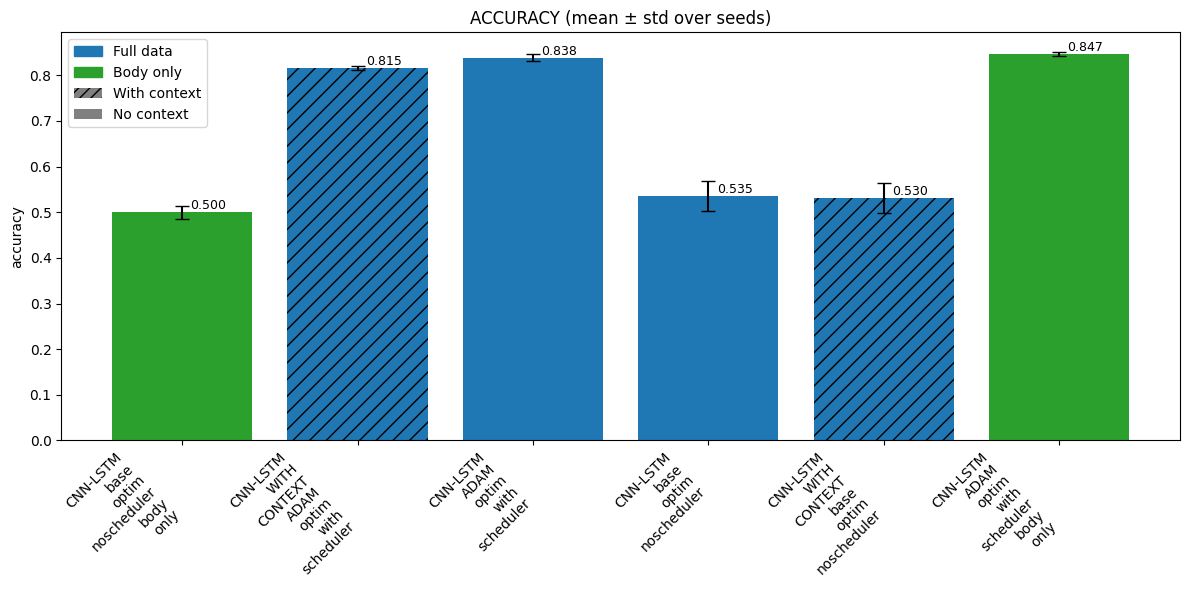

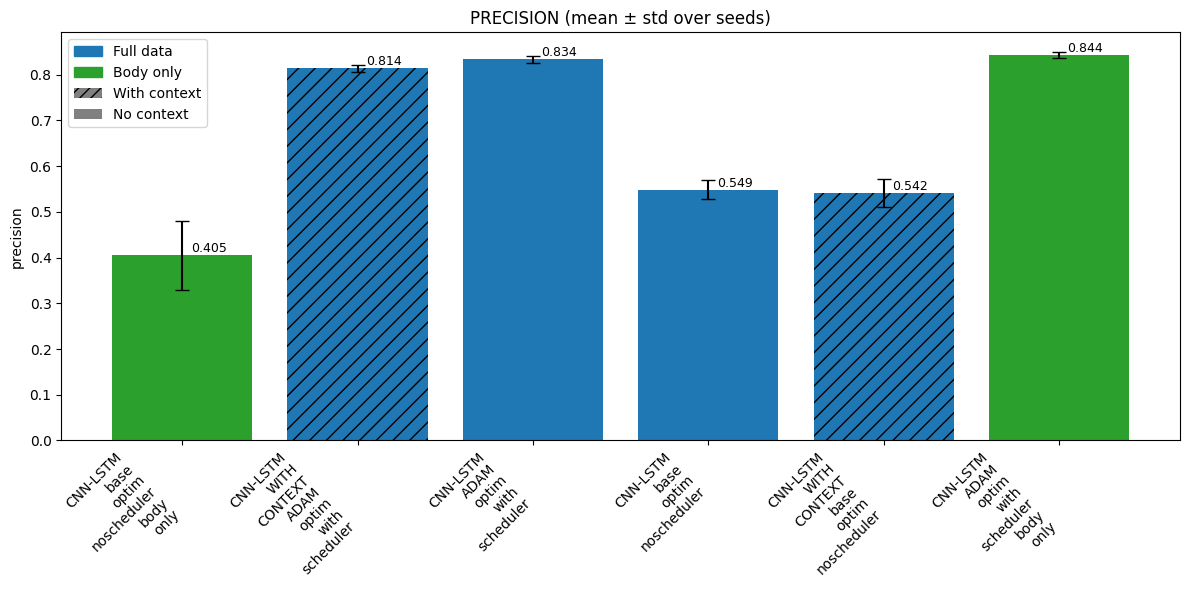

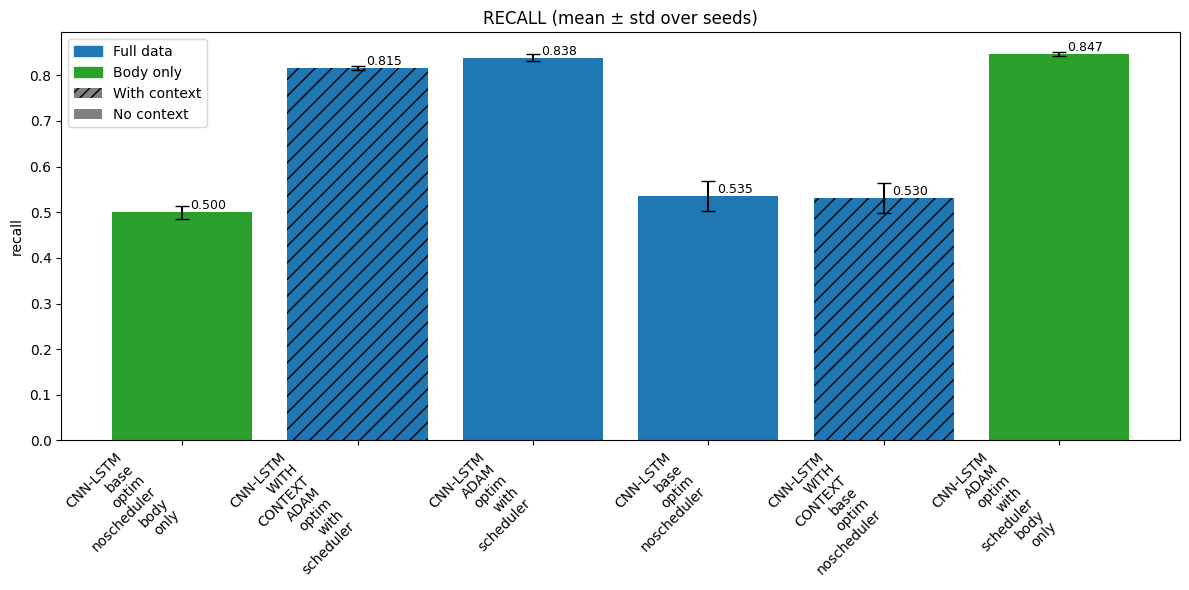

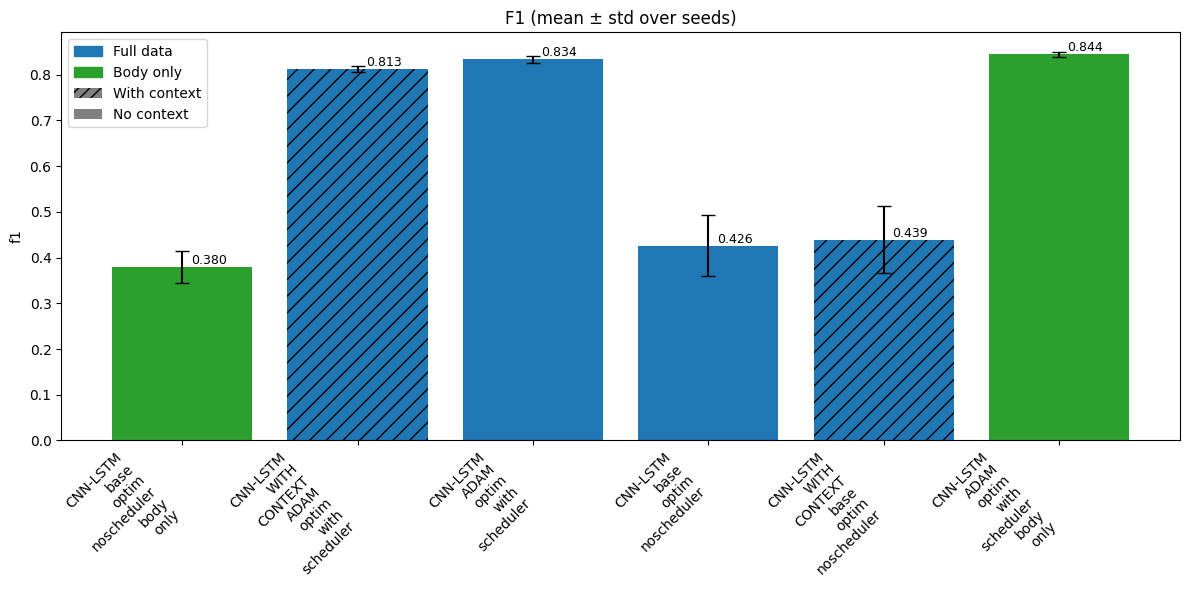

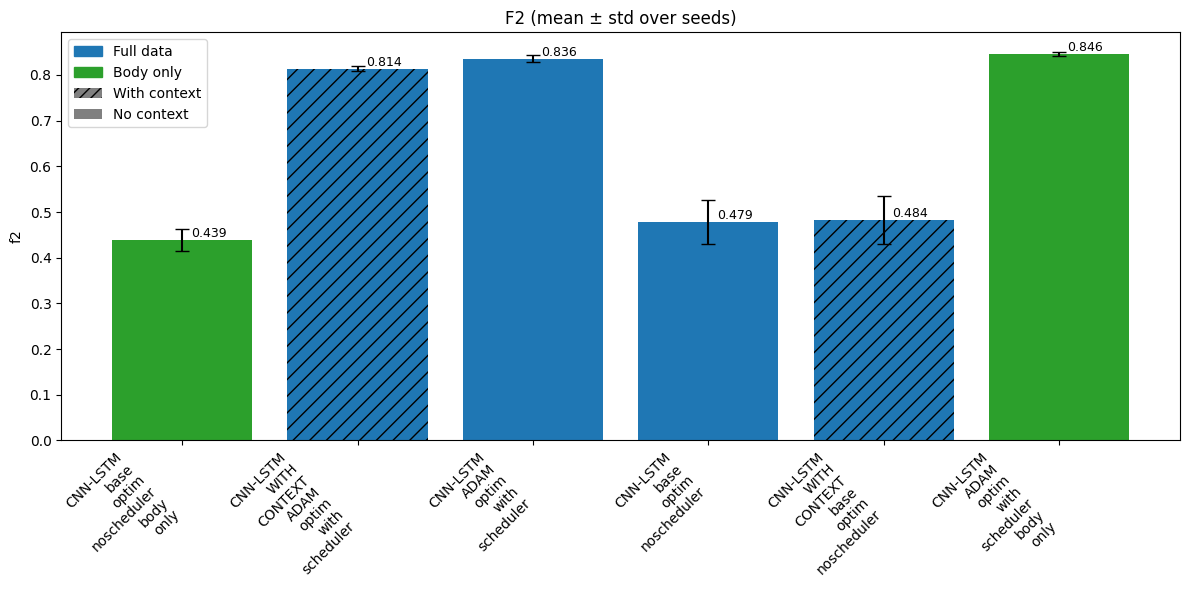

In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# --- parse metadata ---
def parse_model_name(name):
    context = "context" if "WITH_CONTEXT" in name else "no_context"
    data = "body_only" if "body_only" in name else "full_data"
    opt = "adam_sched" if "ADAM_optim_with_scheduler" in name else "base_nosched"
    return context, data, opt

summary_df[["context", "data", "opt"]] = summary_df["model"].apply(
    lambda x: pd.Series(parse_model_name(x))
)

summary_df["label"] = summary_df["model"].str.replace("_", "\n")

# --- color by DATA ---
color_map = {
    "full_data": "tab:blue",
    "body_only": "tab:green"
}
colors = summary_df["data"].map(color_map)

# --- hatch by CONTEXT ---
hatch_map = {
    "context": "//",
    "no_context": ""
}

metrics = ["accuracy", "precision", "recall", "f1", "f2"]

for m in metrics:
    plt.figure(figsize=(12, 6))

    bars = plt.bar(
        summary_df["label"],
        summary_df[f"{m}_mean"],
        yerr=summary_df[f"{m}_std"],
        capsize=5,
        color=colors
    )

    # apply hatching + value labels
    for i, bar in enumerate(bars):
        context_type = summary_df.iloc[i]["context"]
        bar.set_hatch(hatch_map[context_type])

        height = bar.get_height()
        plt.text(
            bar.get_x() + (bar.get_width() / 2) + 0.15,
            height,
            f"{height:.3f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

    plt.ylabel(m)
    plt.title(f"{m.upper()} (mean ± std over seeds)")
    plt.xticks(rotation=45, ha="right")

    # --- legend ---
    data_legend = [
        mpatches.Patch(color="tab:blue", label="Full data"),
        mpatches.Patch(color="tab:green", label="Body only")
    ]

    context_legend = [
        mpatches.Patch(facecolor="gray", hatch="///", label="With context"),
        mpatches.Patch(facecolor="gray", label="No context")
    ]

    plt.legend(handles=data_legend + context_legend, loc="upper left")

    plt.tight_layout()
    plt.savefig(os.path.join(plots_path, f"{m}_comparison.png"))

In [6]:

from sklearn.metrics import confusion_matrix
import seaborn as sns

for group, runs in groups.items():
    for run in runs:
        run_path = os.path.join(results_path, run)
        parquet_path = os.path.join(run_path, "results.parquet")

        if not os.path.exists(parquet_path):
            print(f"Missing: {parquet_path}")
            continue

        df = pd.read_parquet(parquet_path)

        y_true = df["Actual"]
        y_pred = df["Predicted"]

        cm = confusion_matrix(y_true, y_pred)

        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.title(run)

        save_path = os.path.join(plots_path, f"{run}_confusion_matrix.png")
        plt.tight_layout()
        plt.savefig(save_path)
        plt.close()